![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

### Autores: Lorena Gómez Diegoy Marta Orient Cabañas

In [2]:
import gdsfactory as gf
import matplotlib.pyplot as plt

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [3]:
from upvfab.sin300.cband import PDK, cells

#### **1a.** Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 15:27:15.540 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


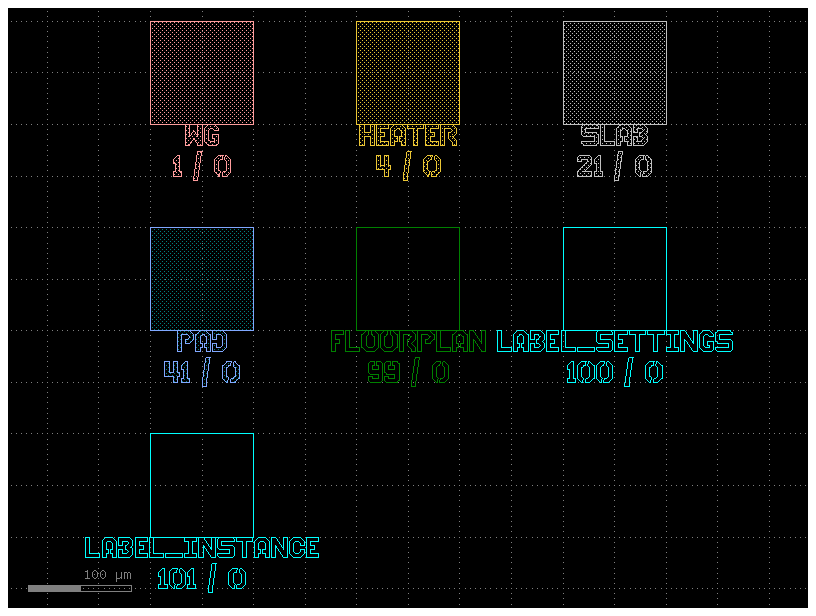

In [4]:
gf.clear_cache()
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 15:27:18.154 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


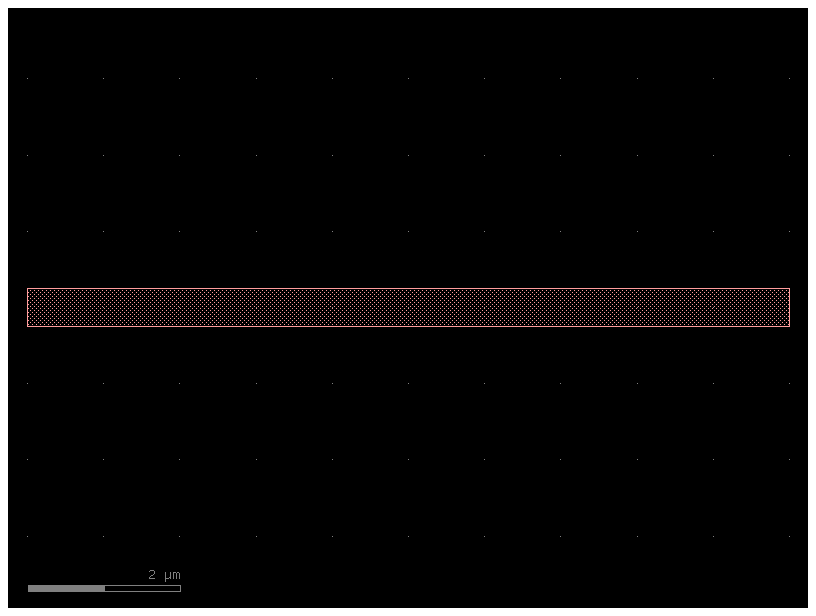

In [5]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 15:27:20.785 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:27:20.830 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


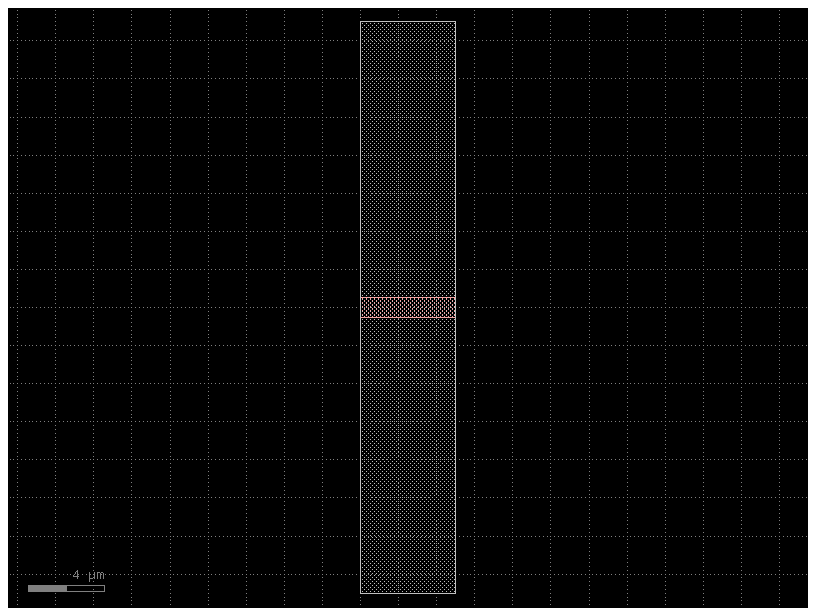

In [6]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [7]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 15:27:25.089 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 15:25:27.636 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


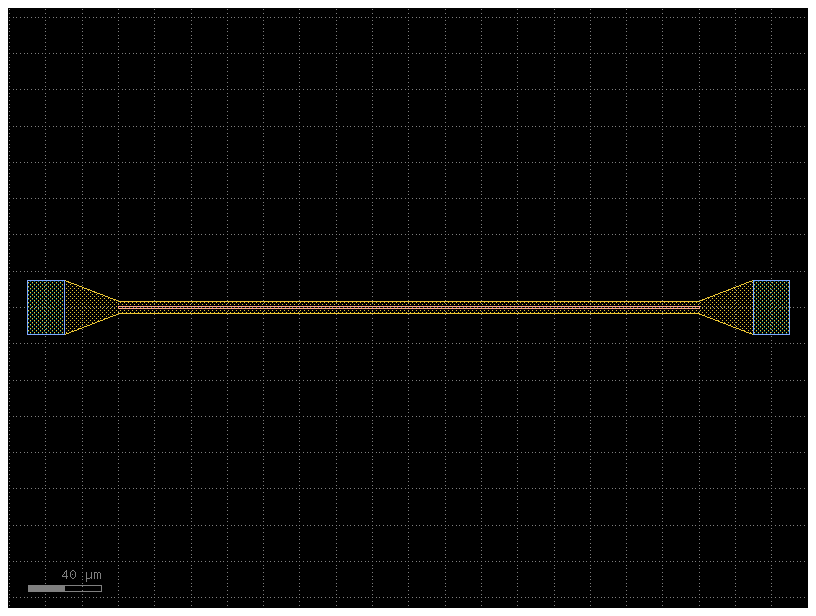

In [106]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

##### 1b.1 Directional Coupler


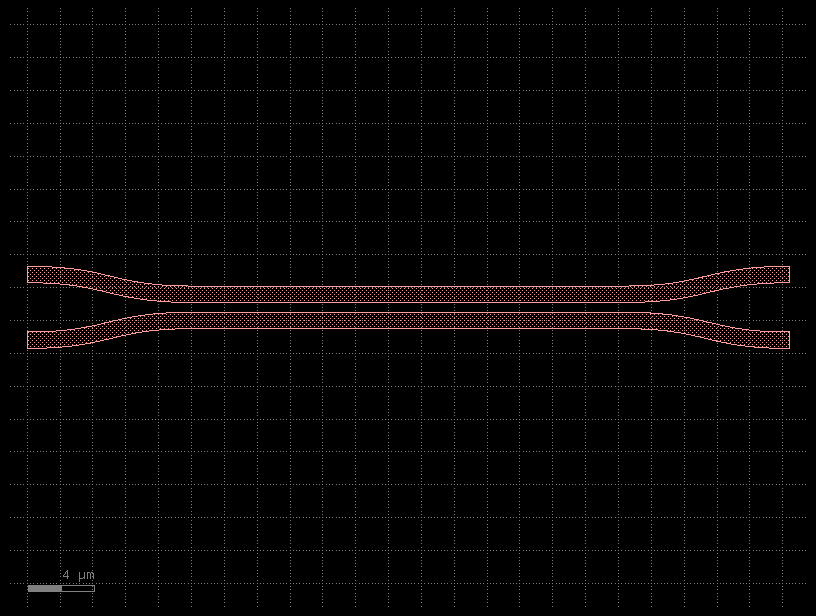

In [8]:
L = 26.389
cs_dc = gf.cross_section.strip(width=1.0, layer="WG")
dc = gf.components.coupler(gap=0.6, length=L, cross_section=cs_dc)

dc.plot()
plt.gcf().set_facecolor("black")
plt.gca().set_facecolor("black")

scene = dc.to_3d()
scene.show()

##### 1b.2 MMI 2x2


2026-06-12 15:27:57.985 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


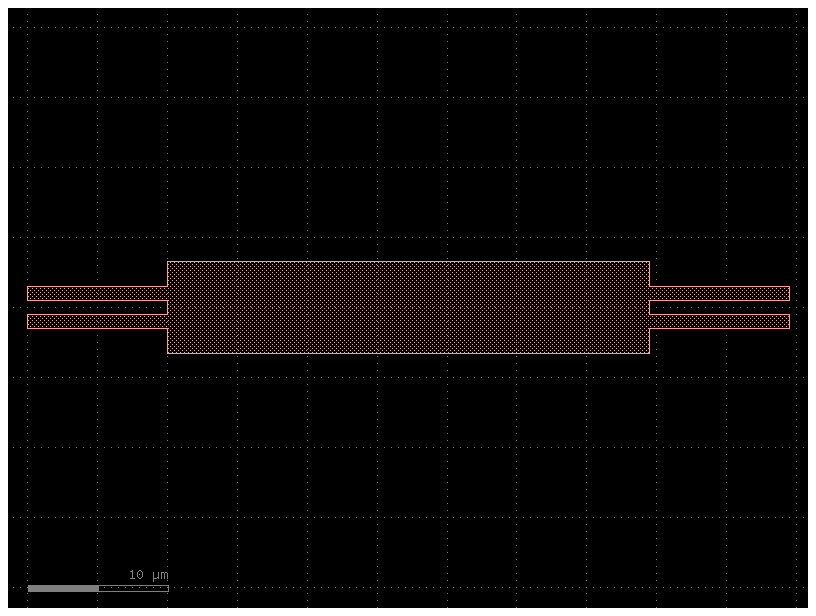

In [9]:
def mmi2x2(
    width=1.0,          
    width_mmi=6.6,      
    length_mmi=34.518,   
    gap_mmi=1.0,        
    cross_section='strip',
) -> gf.Component:
    return gf.components.mmi2x2(
        width=width,
        width_mmi=width_mmi,
        length_mmi=length_mmi,
        gap_mmi=gap_mmi,
        cross_section=cross_section,
    )
  
mmi2x2_ref = mmi2x2()
mmi2x2_ref.plot()
mmi2x2_ref.show()
scene = mmi2x2_ref.to_3d()
scene.show()


##### 1b.3 MZI

2026-06-12 15:28:01.454 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


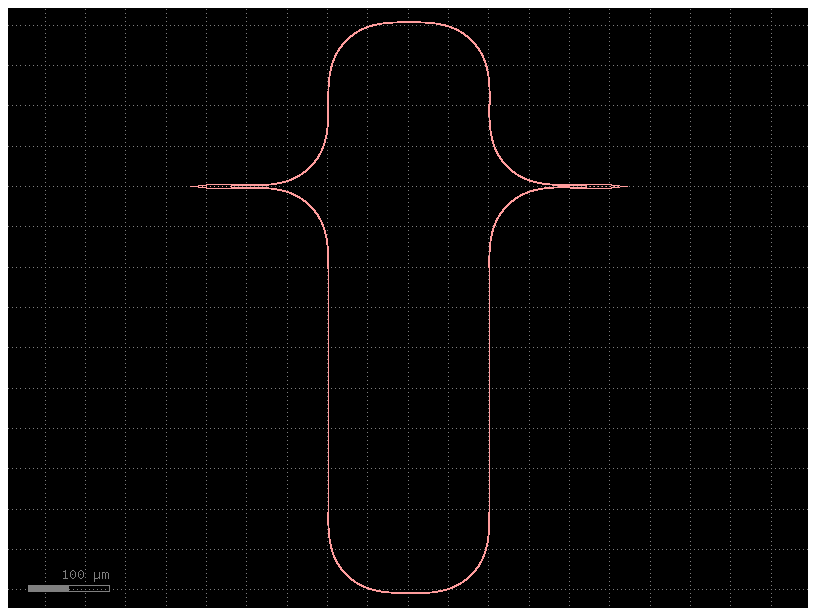

In [10]:
mzi = gf.components.mzi(
    delta_length=600.625,  
    cross_section='strip',
)

mzi.plot()
mzi.show()
scene = mzi.to_3d()
scene.show()


##### 1b.4 Ring Resonator

2026-06-12 15:28:24.258 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


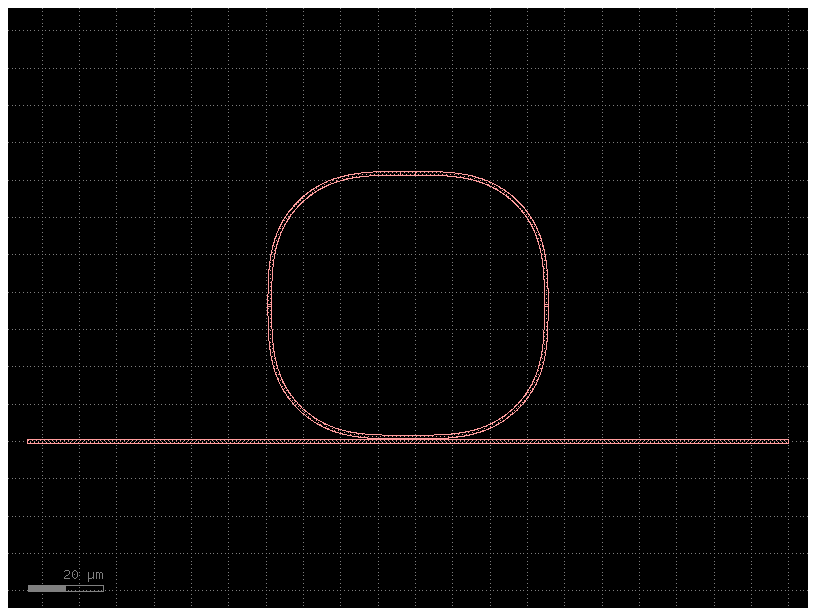

In [13]:


ring = gf.components.ring_single(
    radius=35.0,      # Perimetro de 219.91 um
    gap=0.2,           # Modificada para K=0.5
    cross_section='strip',
)

ring.plot()
ring.show()
scene = ring.to_3d()
scene.show()



## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 15:28:30.138 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


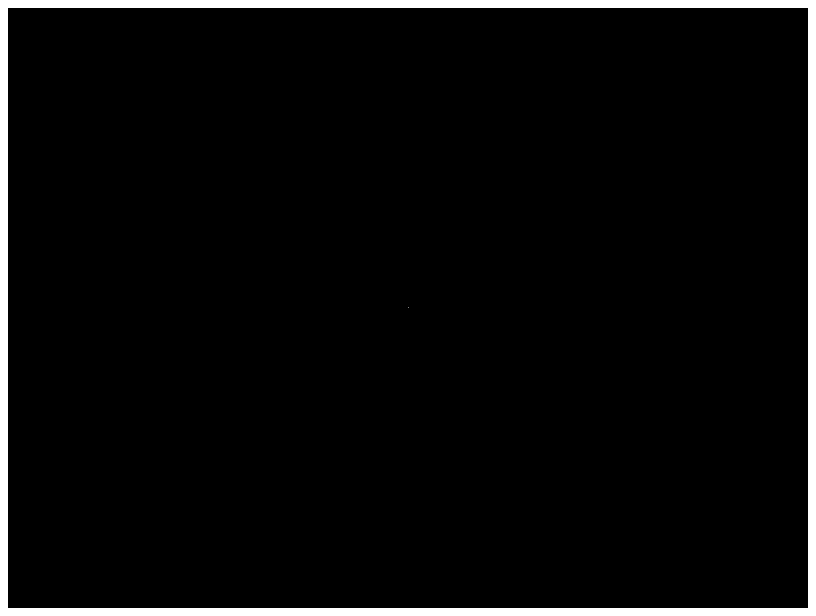

In [14]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 15:28:32.683 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


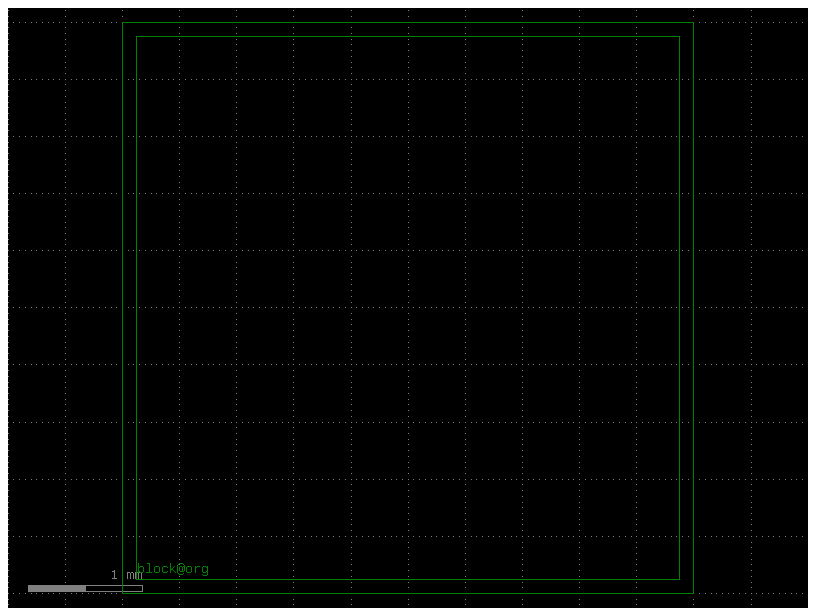

In [15]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 15:28:37.372 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


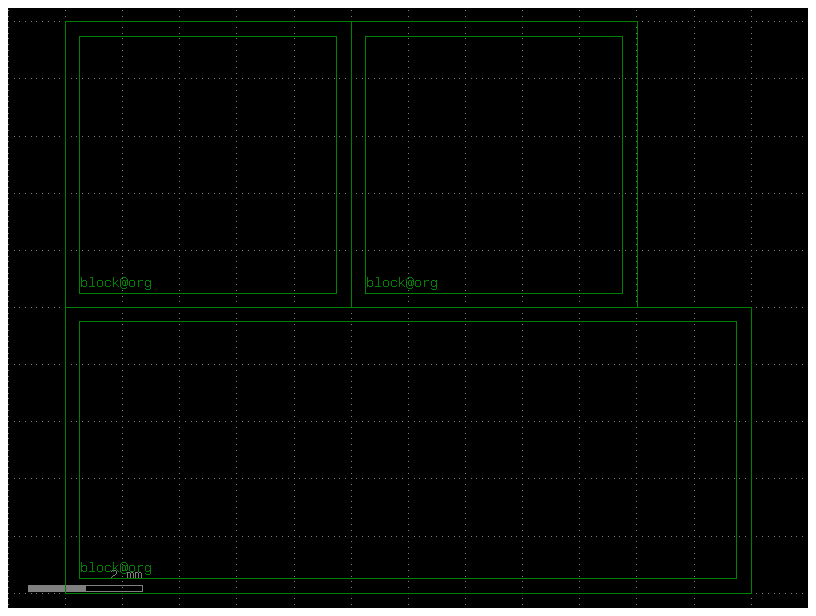

In [16]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


##### **2.b.1** Complete Layout: Directional Coupler

2026-06-12 15:28:40.133 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


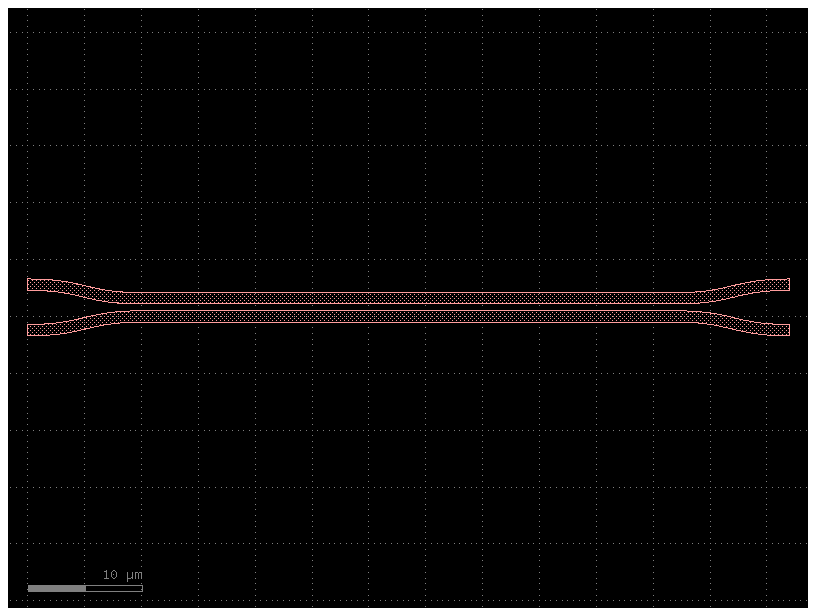

In [17]:
@gf.cell
def dc_50_50(
    width: float = 1.0,
    gap: float = 0.6,
    length: float = 47.01,
) -> gf.Component:
    xs = gf.cross_section.strip(width=width, layer="WG")
    return gf.components.coupler(gap=gap, length=length, cross_section=xs)



dc = dc_50_50()
dc.plot()
dc.show()

##### **2.b.2** Complete Layout: MMI

2026-06-12 16:09:59.564 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


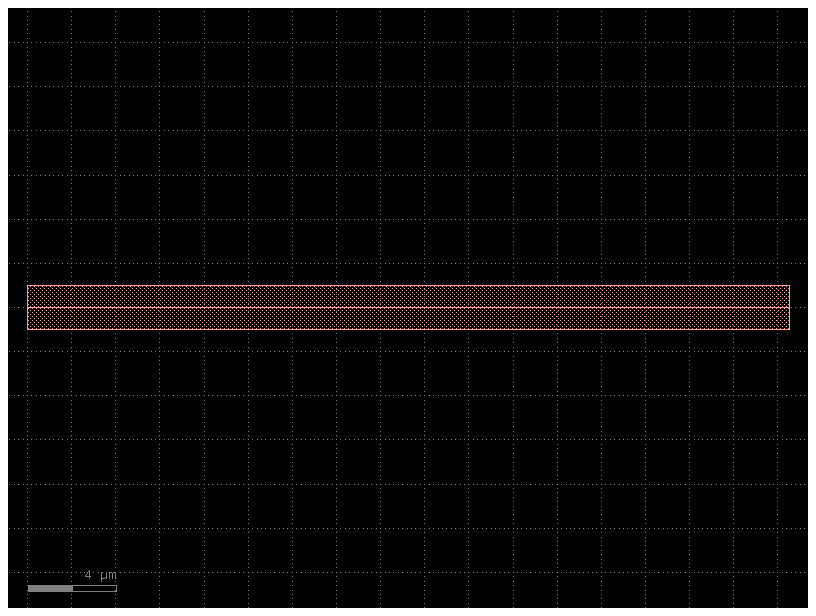

In [72]:

@gf.cell
def mmi2x2(
    width: float = 1.0,           
    width_mmi: float = 6.6,
    length: float = 34.518,
    gap: float = 1.0,
    layer="WG"
):
    xs_wg_b1 = gf.cross_section.strip(width=width, layer=layer)
    layout_mmi2x2 = gf.Component()

    center_spacing_b3 = width * gap

    wg_top_b3 = layout_mmi2x2.add_ref(
        gf.components.straight(length=length, cross_section=xs_wg_b1)
    )
    wg_top_b3.dmovey(center_spacing_b3 / 2)

    wg_bottom_b3 = layout_mmi2x2.add_ref(
        gf.components.straight(length=length, cross_section=xs_wg_b1)
    )
    wg_bottom_b3.dmovey(-center_spacing_b3 / 2)

    layout_mmi2x2.add_port(name="o1", port=wg_bottom_b3.ports["o1"])
    layout_mmi2x2.add_port(name="o2", port=wg_top_b3.ports["o1"])
    layout_mmi2x2.add_port(name="o3", port=wg_top_b3.ports["o2"])
    layout_mmi2x2.add_port(name="o4", port=wg_bottom_b3.ports["o2"])

    return layout_mmi2x2

comp_mmi2x2 = gf.Component()

comp_mmi2x2.add_ref(mmi2x2())
comp_mmi2x2.plot()
comp_mmi2x2.show()

##### **2.b.3** Complete Layout: MZI

2026-06-12 15:44:12.750 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


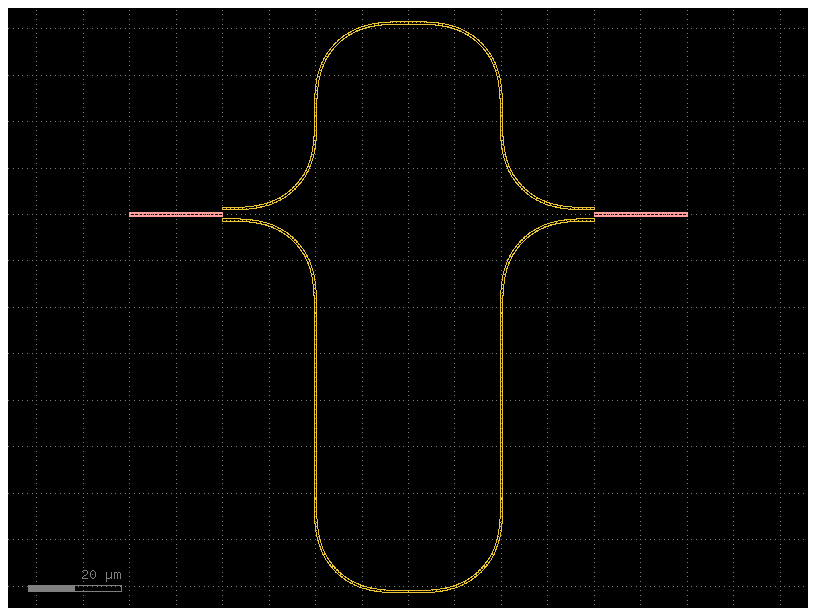

In [39]:
def mzi_layout_b3(
    delta_length=40.0,
    radius=20.0,
    gap=0.5,
    length_dc=20.0,
    width=0.5,
    layer="WG",
):
    xs_wg_b3 = gf.cross_section.strip(width=width, layer=layer)
    mzi_comp_b3 = gf.Component()
    
    y_ring_margin_b3 = (width / 2) + 1

    bend_1_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_1_b1.drotate(270).dmovex(radius).dmovey(y_ring_margin_b3 + radius)

    bend_2_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_2_b1.drotate(90).dmovex(radius).dmovey(y_ring_margin_b3 + radius)

    bend_3_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_3_b1.drotate(180).dmovex(0).dmovey(y_ring_margin_b3 + 2 * radius)

    bend_4_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_4_b1.drotate(0).dmovex(-radius * 2).dmovey(y_ring_margin_b3)

    bend_5_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_5_b1.drotate(180).dmovex(2 * radius).dmovey(-y_ring_margin_b3)

    bend_6_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_6_b1.drotate(0).dmovex(0).dmovey(-y_ring_margin_b3 - 2 * radius - delta_length)

    bend_7_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_7_b1.drotate(270).dmovex(-radius).dmovey(
        -y_ring_margin_b3 - radius - delta_length
    )

    bend_8_b1 = mzi_comp_b3.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg_b3)
    )
    bend_8_b1.drotate(90).dmovex(-radius).dmovey(-y_ring_margin_b3 - radius)

    vertical_right_b1 = mzi_comp_b3.add_ref(
        gf.components.straight(length=delta_length, cross_section=xs_wg_b3)
    )
    vertical_right_b1.drotate(270).dmovex(radius).dmovey(-y_ring_margin_b3 - radius)

    vertical_left_b1 = mzi_comp_b3.add_ref(
        gf.components.straight(length=delta_length, cross_section=xs_wg_b3)
    )
    vertical_left_b1.drotate(90).dmovex(-radius).dmovey(
        -y_ring_margin_b3 - radius - delta_length
    )

    wg_bottom_b3 = mzi_comp_b3.add_ref(
        mmi2x2(length=length_dc, gap=gap, width=width)
    )
    wg_bottom_b3.dmovex(-2 * radius - length_dc).dmovey(0)

    ort=wg_top_b3 = mzi_comp_b3.add_ref(
        mmi2x2(length=length_dc, gap=gap, width=width)
    )
    wg_top_b3.dmovex(2 * radius).dmovey(0)
    mzi_comp_b3.add_port(name="o1", port=wg_bottom_b3.ports["o1"])
    mzi_comp_b3.add_port(name="o2", port=wg_bottom_b3.ports["o2"])
    mzi_comp_b3.add_port(name="o3", port=wg_top_b3.ports["o3"])
    mzi_comp_b3.add_port(name="o4", port=wg_top_b3.ports["o4"])

    
    return mzi_comp_b3

mzi_ref = mzi_layout_b3(delta_length=40.0,
    radius=20.0,
    gap=0.5,
    length_dc=20.0,
    width=0.5,
    layer="HEATER")
mzi_ref.plot()
mzi_ref.show()

##### **2.b.4** Complete Layout: Ring Resonator

2026-06-12 15:46:52.969 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


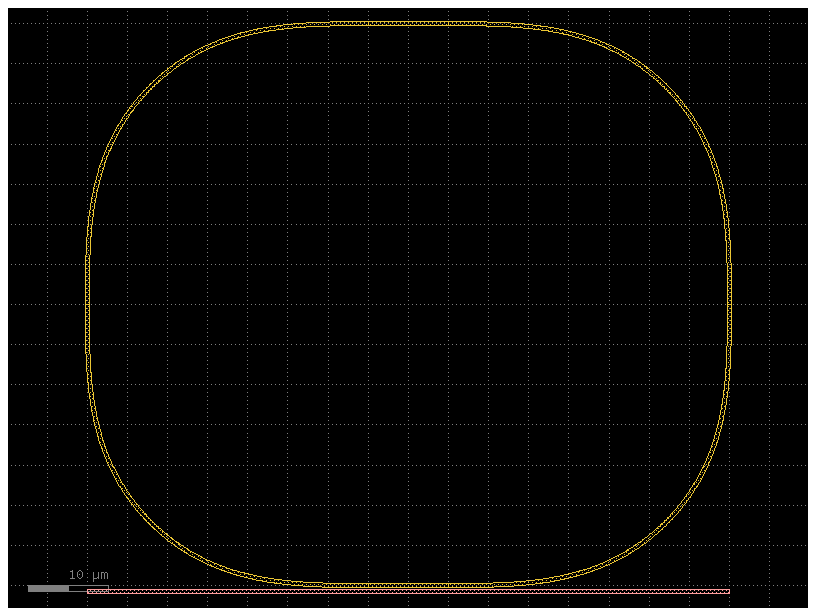

In [45]:
@gf.cell
def ring_all_pass(
    radius=20.0, gap=0.2, width=0.5, length=10.0, layer="WG"
):
    xs_ring_b1 = gf.cross_section.strip(width=width, layer=layer)
    xs_bus_b1 = gf.cross_section.strip(width=width, layer="WG")

    ring_comp_b1 = gf.Component()

    bend_1_ring_b1 = ring_comp_b1.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_ring_b1)
    )

    bend_2_ring_b1 = ring_comp_b1.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_ring_b1)
    ).connect("o1", bend_1_ring_b1.ports["o2"])

    straight_right_b1 = ring_comp_b1.add_ref(
        gf.components.straight(length=length, cross_section=xs_ring_b1)
    ).connect("o1", bend_2_ring_b1.ports["o2"])

    bend_3_ring_b1 = ring_comp_b1.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_ring_b1)
    ).connect("o1", straight_right_b1.ports["o2"])

    bend_4_ring_b1 = ring_comp_b1.add_ref(
        gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_ring_b1)
    ).connect("o1", bend_3_ring_b1.ports["o2"])

    straight_left_b1 = ring_comp_b1.add_ref(
        gf.components.straight(length=length, cross_section=xs_ring_b1)
    ).connect("o1", bend_4_ring_b1.ports["o2"])

    bus_length_b1 = 2 * radius + length
    bus_wg_b1 = ring_comp_b1.add_ref(
        gf.components.straight(length=bus_length_b1, cross_section=xs_bus_b1)
    )

    y_bus_b1 = bend_1_ring_b1.ports["o1"].center[1] - (gap + width)
    x_bus_b1 = bend_4_ring_b1.ports["o1"].center[0]

    bus_wg_b1.dmovex(x_bus_b1).dmovey(y_bus_b1)

    ring_comp_b1.add_port(name="o1", port=bus_wg_b1.ports["o1"])
    ring_comp_b1.add_port(name="o2", port=bus_wg_b1.ports["o2"])

    return ring_comp_b1


ring = ring_all_pass(
    radius= 35.0,
    gap= 0.2,
    layer = "HEATER"
)
ring.plot()
ring.show()

## 3. Complete Layout

2026-06-12 15:47:02.391 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


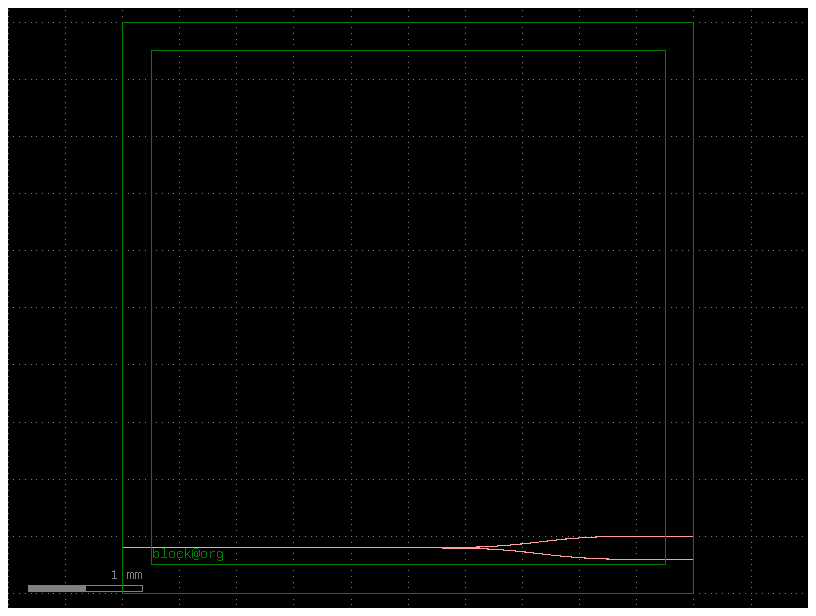

In [46]:
s2qww11cayer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

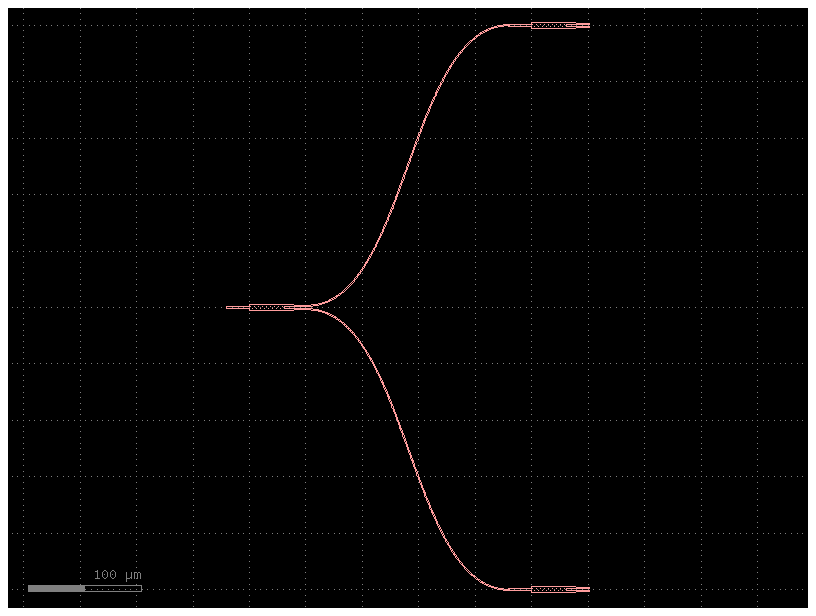

In [ ]:
# Let's create a MMI tree

c = gf.Component("mmi_tree_preview")
c_mmi = cells.mmi1x2()
mmi1 = c.add_ref(c_mmi)
mmi2 = c.add_ref(c_mmi)
mmi3 = c.add_ref(c_mmi)

mmi2.dmovex(250).dmovey(250)
mmi3.dmovex(250).dmovey(-250)

gf.routing.route_single_sbend(component=c, port1=mmi1['o2'], port2=mmi2['o1'], cross_section='strip')
gf.routing.route_single_sbend(component=c, port1=mmi1['o3'], port2=mmi3['o1'], cross_section='strip')
c.plot()

In [ ]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

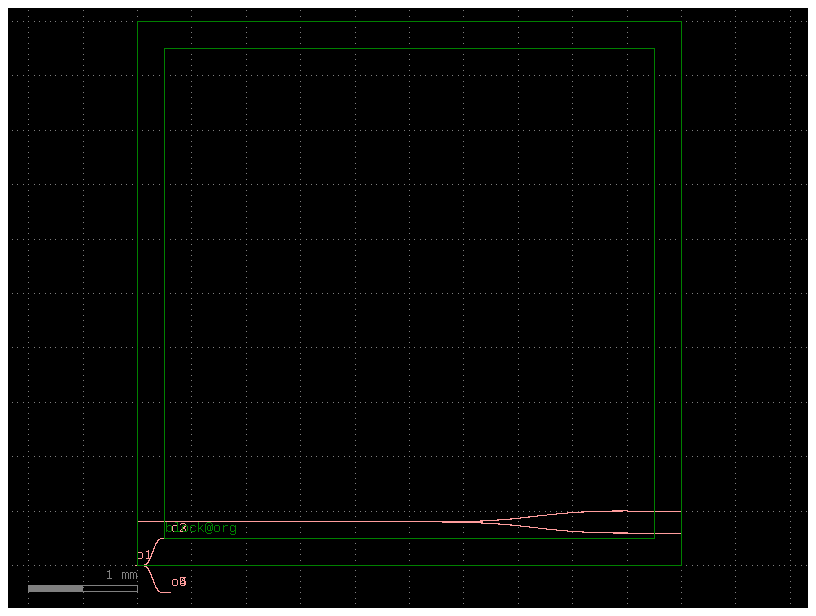

In [ ]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 12:51:16.051 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


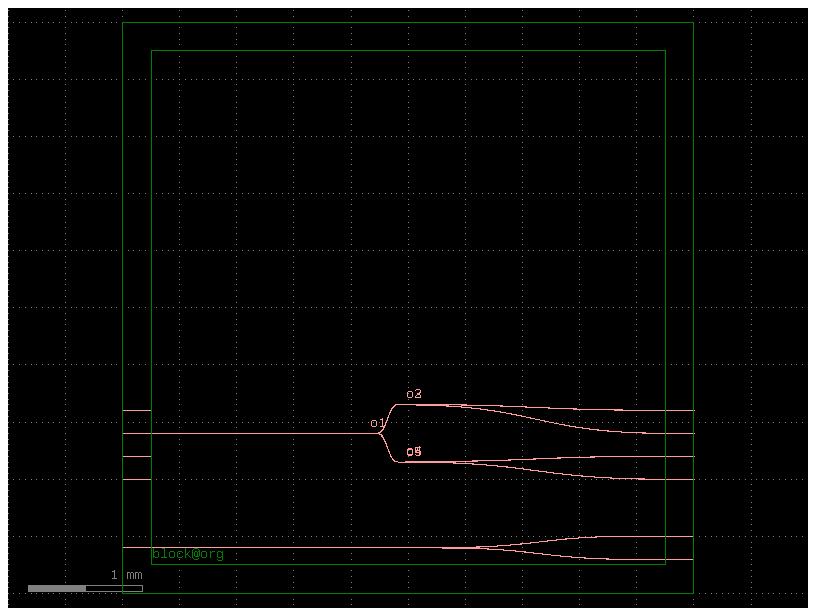

In [ ]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

### Solutions
Here is a complete set of notebook cells for the requested components, the die, and the final floorplan.

In [25]:
gf.clear_cache



<function gdsfactory.clear_cache(kcl: 'kf.KCLayout' = KCLayout(DEFAULT, n=63)) -> 'None'>

### Part a) Creating components

2026-06-12 15:50:25.736 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:50:25.818 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:50:25.896 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:50:25.976 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:50:26.143 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


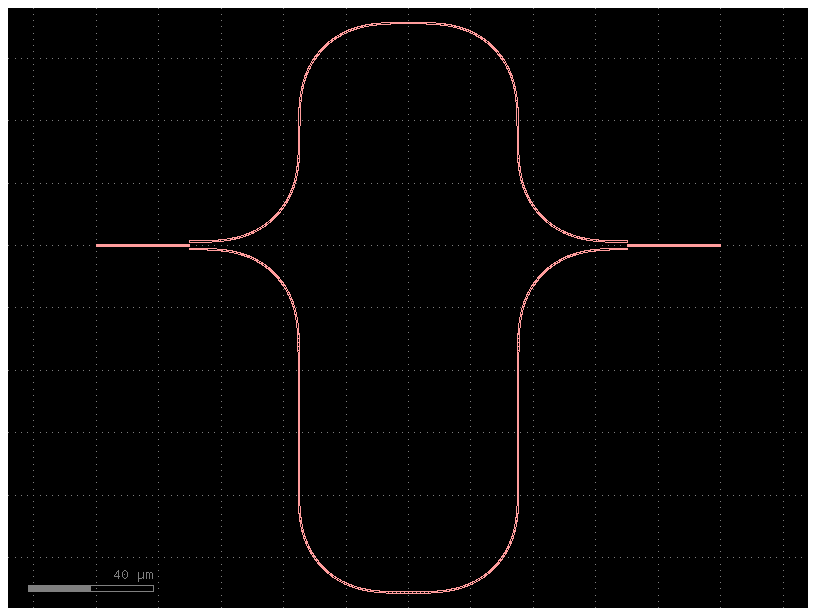

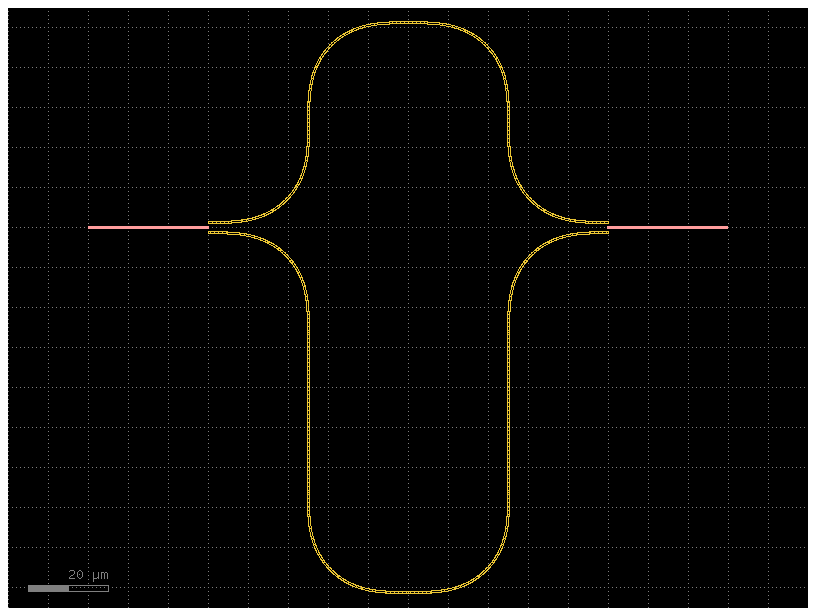

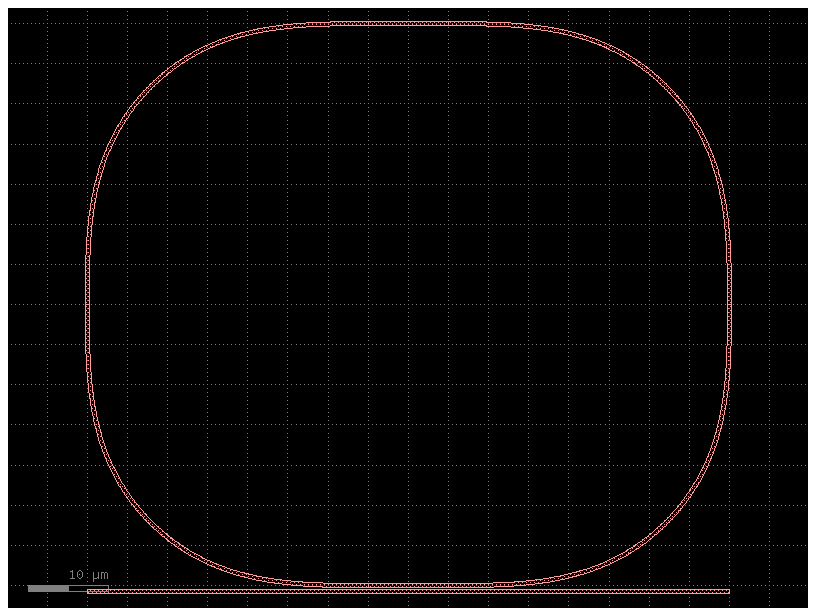

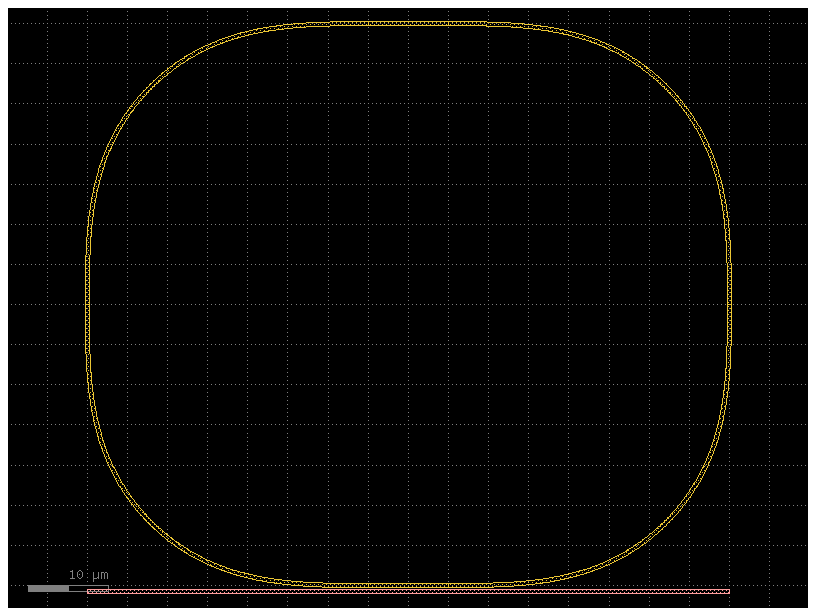

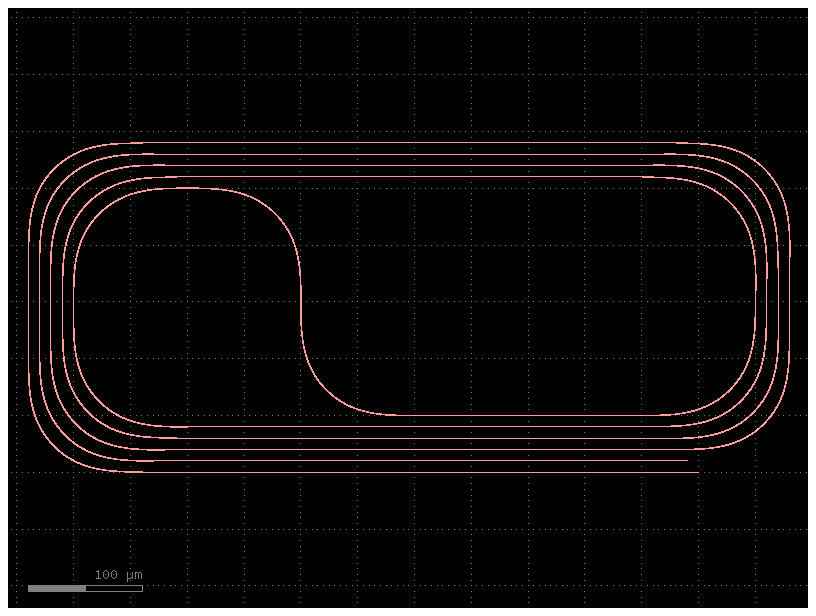

In [51]:
# 1) Unbalanced MZI
mzi_wg = gf.Component()
mzi_wg.add_ref(
    mzi_layout_b3(delta_length=40.0, radius=35.0, gap=0.5,
                  length_dc=30.0, width=0.5, layer="WG")
)
mzi_wg.plot()
mzi_wg.show()
# 2) MZI with thermal tuner
mzi_heater = gf.Component()
mzi_heater.add_ref(
    mzi_layout_b3(delta_length=40.0, radius=25.0, gap=0.5,
                  length_dc=30.0, width=0.5, layer="HEATER")
)
mzi_heater.plot()
mzi_heater.show()
# 3) All-pass ring resonator
mzi_ring_thermal = gf.Component()
mzi_ring_thermal.add_ref(
    ring_all_pass(radius=35.0, gap=0.2, layer="WG")
)

mzi_ring_thermal.plot()
mzi_ring_thermal.show()
# 4) Ring resonator with thermal tuner
mzi_ring_thermal = gf.Component()
mzi_ring_thermal.add_ref(
    ring_all_pass(radius=35.0, gap=0.2, layer="HEATER")
)

mzi_ring_thermal.plot()
mzi_ring_thermal.show()
# 5) Spiral
@gf.cell
def spiral_def(
    length: float = 200.0,
    n_loops: int = 5,
    spacing: float = 10.0,
    width: float = 0.5,
) -> gf.Component:
    c = gf.Component()
    xs = gf.get_cross_section("strip", width=width)
    ref = c << gf.components.spiral(
        length=length,
        n_loops=n_loops,
        spacing=spacing,
        cross_section=xs,
        straight=gf.components.straight,

    )
    c.add_ports(ref.ports)
    return c


spiral = gf.Component()
spiral.add_ref(
    spiral_def(length=200.0, n_loops=5, spacing=10.0, width=0.5)
)
spiral.plot()
spiral.show()


### Part b) Creating die


2026-06-12 15:56:58.991 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


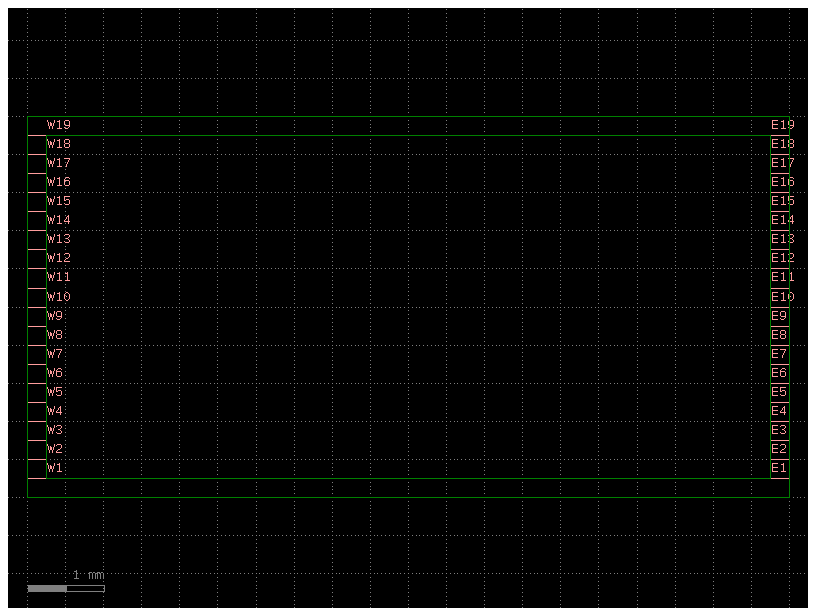

In [68]:
WG_WIDTH = 1.0  # ancho de guia

@gf.cell
def die_io(
    die_L: float = 10_000.0,   
    die_W: float = 5_000.0,    
    border: float = 250.0,
    io_pitch: float = 250.0,
    layer_box: str = "FLOORPLAN",
) -> gf.Component:
    
    c = gf.Component()
    tmp = gf.Component()
    obox = tmp.add_ref(gf.components.rectangle(size=(die_L, die_W), layer=layer_box))
    ibox = tmp.add_ref(
        gf.components.rectangle(size=(die_L - 2*border, die_W - 2*border), layer=layer_box)
    ).dmovex(border).dmovey(border)
    frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    c.add_ref(frame)

    n_io = int((die_W - 2*border) // io_pitch) + 1   # 19 para W = 5 mm

    arr = gf.components.straight_array(
        n=n_io, spacing=io_pitch - WG_WIDTH, length=border, cross_section="strip"
    )
    in_arr = c.add_ref(arr).dmovey(border)                            
    out_arr = c.add_ref(arr).dmovex(die_L - border).dmovey(border)    

    w_ports = sorted([p for p in in_arr.ports if p.orientation == 0], key=lambda p: p.center[1])
    e_ports = sorted([p for p in out_arr.ports if p.orientation == 180], key=lambda p: p.center[1])
    for i, p in enumerate(w_ports, start=1):
        c.add_port(f"W{i}", port=p)
    for i, p in enumerate(e_ports, start=1):
        c.add_port(f"E{i}", port=p)
    return c

    gf.clear_cache()

d = die_io()
d.draw_ports()   
d.plot()         
d.show()      

### Part c) Floorplanning and die layout


/tmp/ipykernel_114839/3237103391.py:111: UserWarning: No registered width taper for layer 1. Skipping.
  connect(die_host.ports[f"W{wi}"],   sp.ports[lo])
/tmp/ipykernel_114839/3237103391.py:112: UserWarning: No registered width taper for layer 1. Skipping.
  connect(die_host.ports[f"W{wi+1}"], sp.ports[hi])
/tmp/ipykernel_114839/3237103391.py:118: UserWarning: No registered width taper for layer 1. Skipping.
  connect(die_host.ports[f"E{ei}"],   rng.ports[lo])


2026-06-12 16:26:51.709 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


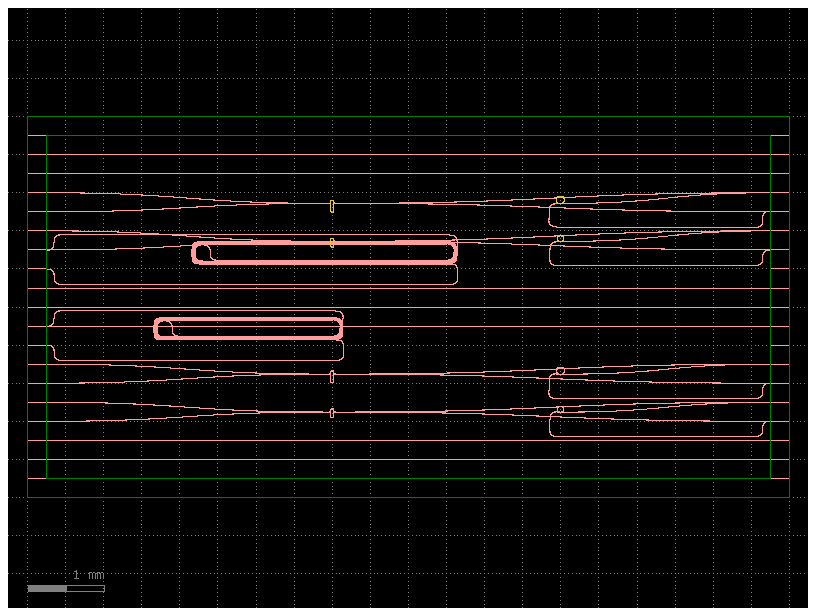

In [85]:
gf.clear_cache()
final_layout = gf.Component()
die_host = final_layout.add_ref(die_io())

XS = "strip"

# helper Y real de cada puerto
def y_port(i):
    return 250 + (i - 1) * 249.0

# ============================================================
# c2) 3 sets de 3 guías rectas (puertos W1-3, W9-11, W17-19)
# ============================================================
for i in (1, 2, 3, 9, 10, 11, 17, 18, 19):
    gf.routing.route_single(
        final_layout,
        die_host.ports[f"W{i}"],
        die_host.ports[f"E{i}"],
        cross_section=XS,
        allow_width_mismatch=True,
    )

# ============================================================
# helper de routing universal
# ============================================================
def connect(p1, p2):
    diff = abs(abs(p1.orientation - p2.orientation) - 180)
    if diff < 0.1:
        gf.routing.route_single_sbend(
            final_layout, port1=p1, port2=p2,
            allow_width_mismatch=True,
        )
    else:
        gf.routing.route_single(
            final_layout, p1, p2,
            cross_section=XS,
            allow_width_mismatch=True,
        )

# ============================================================
# c3) Componentes — X centrada en el die (x ~ 5000)
# ============================================================

mzi_1 = final_layout.add_ref(
    mzi_layout_b3(delta_length=40.0, radius=20.0, gap=0.5,
                  length_dc=20.0, width=0.5, layer="WG")
)
mzi_1.dmovex(4000).dmovey(y_port(4) + (y_port(5) - y_port(4)) / 2)

mzi_2 = final_layout.add_ref(
    mzi_layout_b3(delta_length=80.0, radius=20.0, gap=0.5,
                  length_dc=20.0, width=0.5, layer="WG")
)
mzi_2.dmovex(4000).dmovey(y_port(6) + (y_port(7) - y_port(6)) / 2)


mzi_h1 = final_layout.add_ref(
    mzi_layout_b3(delta_length=40.0, radius=20.0, gap=0.5,
                  length_dc=20.0, width=0.5, layer="HEATER")
)
mzi_h1.dmovex(4000).dmovey(y_port(13) + (y_port(14) - y_port(13)) / 2)

mzi_h2 = final_layout.add_ref(
    mzi_layout_b3(delta_length=80.0, radius=20.0, gap=0.5,
                  length_dc=20.0, width=0.5, layer="HEATER")
)
mzi_h2.dmovex(4000).dmovey(y_port(15) + (y_port(16) - y_port(15)) / 2)

spiral_1 = final_layout.add_ref(spiral_def(length=2000.0))
spiral_1.dmovex(2000).dmovey(y_port(8) + (y_port(9) - y_port(8)) / 2)
spiral_2 = final_layout.add_ref(spiral_def(length=3000.0))
spiral_2.dmovex(2500).dmovey(y_port(12) + (y_port(13) - y_port(12)) / 2)
ring_1 = final_layout.add_ref(ring_all_pass(radius=35.0, gap=0.2))
ring_1.dmovex(7000).dmovey(y_port(4) + (y_port(5) - y_port(4)) / 2)

ring_2 = final_layout.add_ref(ring_all_pass(radius=45.0, gap=0.2))
ring_2.dmovex(7000).dmovey(y_port(6) + (y_port(7) - y_port(6)) / 2)

ring_h1 = final_layout.add_ref(ring_all_pass(radius=35.0, gap=0.2, layer="HEATER"))
ring_h1.dmovex(7000).dmovey(y_port(13) + (y_port(14) - y_port(13)) / 2)
ring_h2 = final_layout.add_ref(ring_all_pass(radius=45.0, gap=0.2, layer="HEATER"))
ring_h2.dmovex(7000).dmovey(y_port(15) + (y_port(16) - y_port(15)) / 2)

# ============================================================
# c4) Routing
# ============================================================

# MZIs (2 puertos W + 2 puertos E por cada MZI)
for mzi, wi, ei in [(mzi_1, 4, 4), (mzi_2, 6, 6),
                    (mzi_h1, 13, 13), (mzi_h2, 15, 15)]:
    connect(die_host.ports[f"W{wi}"],   mzi.ports["o1"])
    connect(die_host.ports[f"W{wi+1}"], mzi.ports["o2"])
    connect(die_host.ports[f"E{ei}"],   mzi.ports["o3"])
    connect(die_host.ports[f"E{ei+1}"], mzi.ports["o4"])

# Spirals (reflectivos: ambos puertos al lado W)
for sp, wi in [(spiral_1, 8), (spiral_2, 12)]:
    lo, hi = sorted(["o1","o2"], key=lambda p: sp.ports[p].center[1])
    connect(die_host.ports[f"W{wi}"],   sp.ports[lo])
    connect(die_host.ports[f"W{wi+1}"], sp.ports[hi])

# Rings (reflectivos: ambos puertos al lado E)
for rng, ei in [(ring_1, 4), (ring_2, 6),
                (ring_h1, 13), (ring_h2, 15)]:
    lo, hi = sorted(["o1","o2"], key=lambda p: rng.ports[p].center[1])
    connect(die_host.ports[f"E{ei}"],   rng.ports[lo])
    connect(die_host.ports[f"E{ei+1}"], rng.ports[hi])



# ============================================================
final_layout.plot()
final_layout.show()